# Latent State Modelling of Reddit Discourse Around IIT Suicides
### How does collective online behavior evolve after a suicide event at an IIT?

---

## Why are we doing this?

When a suicide is reported at an IIT, Reddit communities don't respond uniformly or statically.
There is a **pattern** that communities go through:

1. **Acute shock** (0–3 days): Raw reactions, information sharing, blame, urgent empathy
2. **Active discourse** (4–14 days): Organised accusations, policy discussion, mobilisation
3. **Absorption** (15–30 days): Reflection, personal mental health sharing, grief
4. **Recovery / fading** (31d+): Institutional discourse, residual speculation

The comment categories in this dataset are:
*S1 Sympathy, S2 Information, S3 Speculation, S4 Accusation/Blame, S5 Mobilisation,
S6 Indifference, S7 Irrelevant, S8 Personal Reflection, S9 Institutional Policy*

**Our goal**: Model the *proportion* of each category as a function of time since the
suicide event. We expect early phases to be dominated by **S4 Accusation** and **S2 Information**,
shifting toward **S1 Sympathy**, **S8 Personal Reflection**, and **S9 Institutional Policy** over time.

---

## Formal Setup

Let:
- **t** = time phase since incident (acute → active → absorbed → recovery)
- **X_t** = incident salience at time t (decays from 1 at t=0)
- **S_t** = latent collective response state at time t
- **B_t** = observed vector of category proportions at time t

We model:
```
P(S_t | S_{t-1}, X_t)   ← how states transition, driven by fading incident intensity
P(B_t | S_t)             ← what category proportions each state produces
```

This is an **Input-Output Hidden Markov Model (IOHMM)**, identical in structure
to the natural-disaster tweet model, adapted for Reddit suicide discourse.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.special import logsumexp
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13,
                     "axes.labelsize": 11, "legend.fontsize": 9})

# ── Category definitions ────────────────────────────────────────────────────
CATEGORY_ORDER = ["S1","S2","S3","S4","S5","S6","S7","S8","S9"]
CATEGORY_LABELS = {
    "S1": "Sympathy & Support",
    "S2": "Information Sharing",
    "S3": "Speculation / Cause",
    "S4": "Accusation / Blame",
    "S5": "Mobilization / Action",
    "S6": "Indifference / Low-effort",
    "S7": "Irrelevant",
    "S8": "Personal Reflection",
    "S9": "Institutional / Policy",
}
N_CATS = len(CATEGORY_ORDER)

PHASE_ORDER = ["acute", "active", "absorbed", "recovery"]
PHASE_DAYS  = {"acute": "0–3d", "active": "4–14d",
               "absorbed": "15–30d", "recovery": "31d+"}

COLORS = sns.color_palette("tab10", n_colors=N_CATS)

print("Setup complete.")
print(f"Tracking {N_CATS} response categories across {len(PHASE_ORDER)} time phases.")


Setup complete.
Tracking 9 response categories across 4 time phases.


## Data Loading & Incident-Anchored Time Axis

We load the categorised Reddit dataset and compute **days since incident** for every comment.

### Key design decision: incident anchoring
Unlike natural disasters with known start dates, suicide events on Reddit are identified
by **weekly comment spikes** — the week with the highest comment volume per institution
is treated as the incident anchor date.

This converts absolute comment timestamps into a *relative time axis* comparable
across all 6 institutions.

### Phase definitions
| Phase | Days | Psychological meaning |
|-------|------|-----------------------|
| acute | 0–3 | Immediate shock, first reports, raw reactions |
| active | 4–14 | Peak discourse, blame, policy debate |
| absorbed | 15–30 | Grief, personal reflection, fatigue |
| recovery | 31+ | Institutional memory, residual discussion |

### Incident salience X_t
Salience decays exponentially from the incident date:
```
X_t = exp(−λ · days_since_incident),   λ = log(2)/7
```
At t=0: X=1.0. At day 7: X=0.5. At day 30: X≈0.05.


In [ ]:
# ── Load categorised data ───────────────────────────────────────────────────
df_raw = pd.read_csv("/content/reddit_categorised.csv")
df_raw["datetime"] = pd.to_datetime(df_raw["created_utc"], unit="s")
df_raw["institution"] = df_raw["institution"].astype(str).str.strip()

print("Columns:", df_raw.columns.tolist())
print(f"Total comments: {len(df_raw):,}")
print()
print("Comments per institution:")
print(df_raw["institution"].value_counts().to_string())

# ── Incident anchors ─────────────────────────────────────────────────────────
# Identified from weekly spike analysis (highest activity week per institution).
# These represent the week when the suicide event peaked on Reddit.
INCIDENT_ANCHORS = {
    "BITS":          pd.Timestamp("2025-03-03"),
    "IIT Bombay":    pd.Timestamp("2026-02-02"),
    "IIT Delhi":     pd.Timestamp("2026-03-09"),
    "IIT Kanpur":    pd.Timestamp("2025-12-29"),
    "IIT Kharagpur": pd.Timestamp("2026-04-13"),
    "VIT":           pd.Timestamp("2025-07-17"),
}

# ── Build incident-anchored dataset ─────────────────────────────────────────
WINDOW_BEFORE = 7    # days before spike to include (pre-incident chatter)
WINDOW_AFTER  = 180  # days after spike to include

rows = []
for inst, anchor in INCIDENT_ANCHORS.items():
    grp = df_raw[df_raw["institution"] == inst].copy()
    for _, row in grp.iterrows():
        days = (row["datetime"] - anchor).total_seconds() / 86400
        if -WINDOW_BEFORE <= days <= WINDOW_AFTER:
            row2 = row.copy()
            row2["incident_id"]         = inst
            row2["anchor_date"]         = anchor
            row2["days_since_incident"] = days
            rows.append(row2)

df = pd.DataFrame(rows).reset_index(drop=True)

# Phase bins
bins   = [-WINDOW_BEFORE - 0.01, 3, 14, 30, WINDOW_AFTER + 1]
labels = PHASE_ORDER
df["time_phase"] = pd.cut(df["days_since_incident"], bins=bins, labels=labels)
df["time_phase"] = pd.Categorical(df["time_phase"], categories=PHASE_ORDER, ordered=True)

# Incident salience
lam = np.log(2) / 7.0
df["incident_salience"] = np.exp(-lam * df["days_since_incident"].clip(lower=0))

print(f"\nIncident-anchored dataset: {len(df):,} comments")
print()
print("Comments per incident × phase:")
print(df.groupby(["incident_id","time_phase"], observed=True).size().unstack(fill_value=0).to_string())


Columns: ['comment_id', 'parent_id', 'author', 'body', 'score', 'created_utc', 'institution', 'topic_id', 'category_code', 'category_label', 'datetime']
Total comments: 3,798

Comments per institution:
institution
IIT Kharagpur    1020
Unknown           691
IIT Kanpur        678
IIT Bombay        618
BITS              366
VIT               266
IIT Delhi         159

Incident-anchored dataset: 2,297 comments

Comments per incident × phase:
time_phase     acute  active  absorbed  recovery
incident_id                                     
BITS               0     124         0        66
IIT Bombay       158     120        12         0
IIT Delhi          0     114         0         0
IIT Kanpur       333       0        66        87
IIT Kharagpur      0     951         0         0
VIT              134      18         0       114


## Category Proportions Over Time

For each (incident, time_phase) pair we compute:
```
proportion(category, phase, incident) = count(category in phase) / total comments in phase
```

**Why proportions, not raw counts?**
Incidents with more media coverage generate more comments overall.
Proportions normalise this out and give us the *relative salience* of each
response type within each window — the signal we actually care about.


In [ ]:
# ── Compute proportions ─────────────────────────────────────────────────────
prop = (
    df.groupby(["incident_id", "time_phase", "category_code"], observed=True)
      .size()
      .reset_index(name="count")
)

phase_totals = (
    df.groupby(["incident_id", "time_phase"], observed=True)
      .size()
      .reset_index(name="phase_total")
)

prop = prop.merge(phase_totals, on=["incident_id", "time_phase"])
prop["proportion"] = prop["count"] / prop["phase_total"]
prop["time_phase"]  = pd.Categorical(prop["time_phase"], categories=PHASE_ORDER, ordered=True)

# ── Aggregate across incidents ───────────────────────────────────────────────
agg = (
    prop.groupby(["time_phase", "category_code"], observed=True)["proportion"]
        .agg(["mean", "std", "count"])
        .reset_index()
)
agg["se"]         = agg["std"] / np.sqrt(agg["count"])
agg["time_phase"] = pd.Categorical(agg["time_phase"], categories=PHASE_ORDER, ordered=True)
agg = agg.sort_values(["category_code", "time_phase"])

print("Category proportion table (mean across incidents):")
pivot = agg.pivot_table(index="category_code", columns="time_phase",
                         values="mean", aggfunc="first")
pivot.index = [f"{c}: {CATEGORY_LABELS[c]}" for c in pivot.index]
print(pivot.round(3).to_string())


Category proportion table (mean across incidents):
time_phase                     acute  active  absorbed  recovery
S1: Sympathy & Support         0.077   0.086     0.167     0.063
S2: Information Sharing        0.157   0.122     0.295     0.148
S3: Speculation / Cause        0.133   0.201     0.182     0.143
S4: Accusation / Blame         0.174   0.154     0.273     0.245
S5: Mobilization / Action      0.050   0.062     0.091     0.018
S6: Indifference / Low-effort  0.119   0.098     0.106     0.126
S7: Irrelevant                 0.204   0.296     0.220     0.237
S8: Personal Reflection        0.026   0.060       NaN     0.035
S9: Institutional / Policy     0.085   0.058     0.045     0.088


## Proportion Trajectories Over Time

How does each response category wax and wane as time passes since the incident?

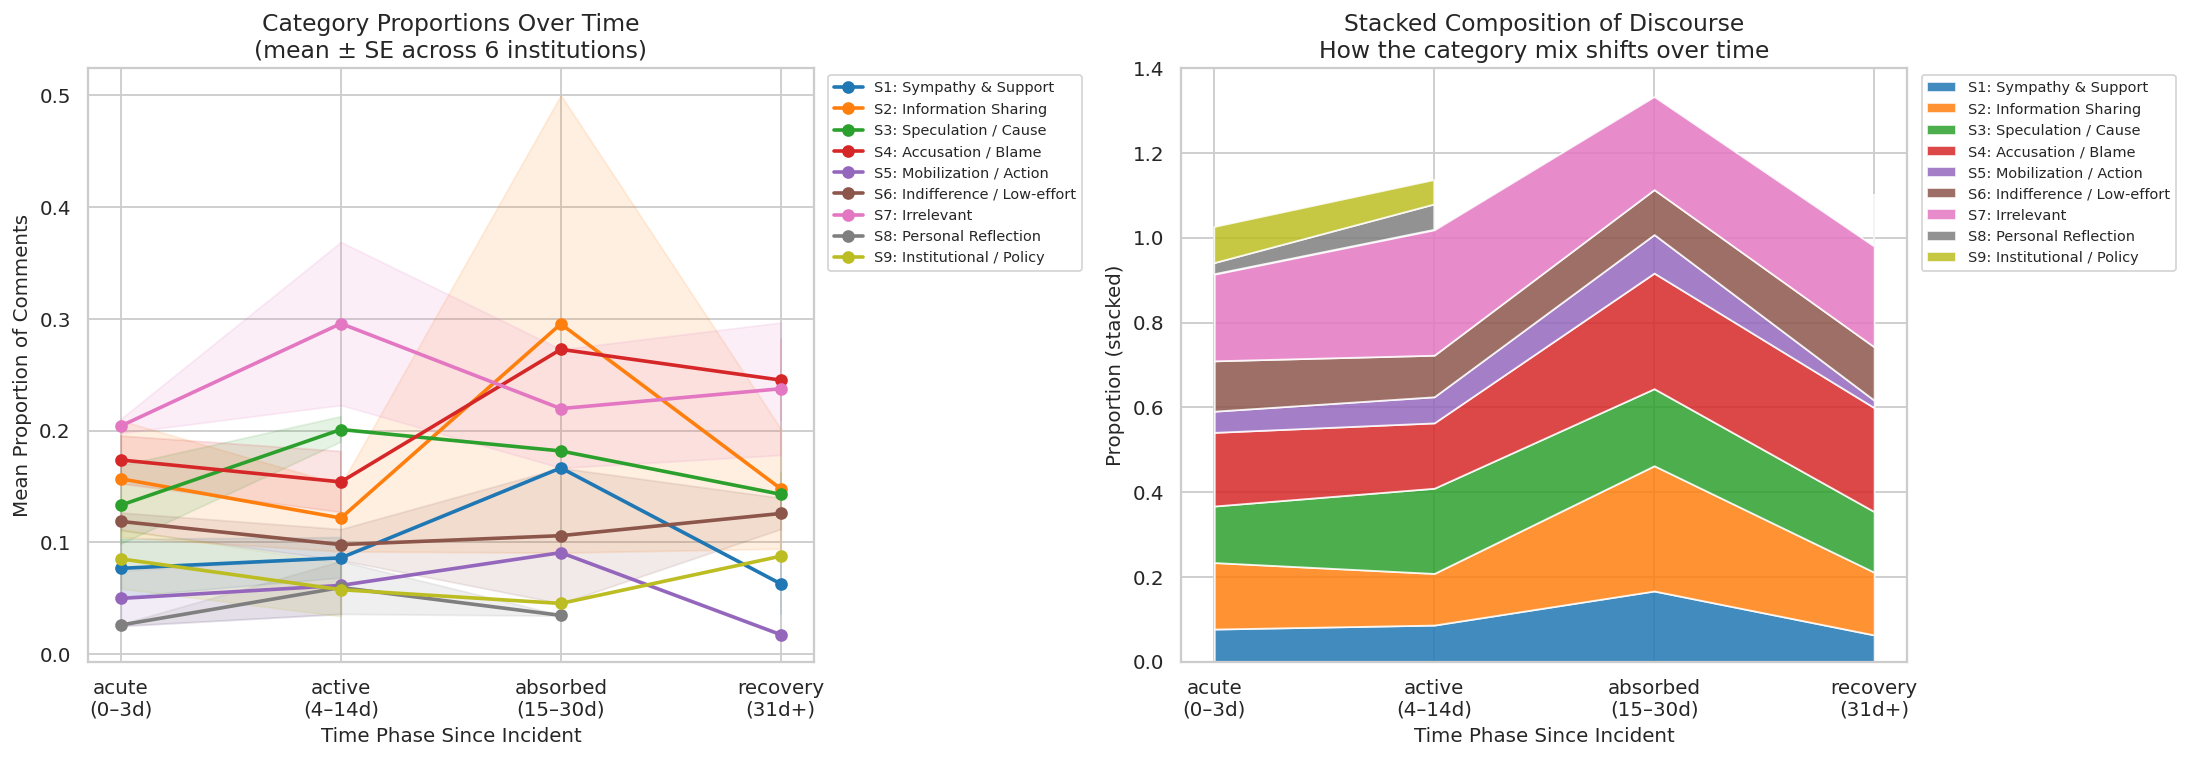

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Line plot with error bands ───────────────────────────────────────────────
ax = axes[0]
for i, cat in enumerate(CATEGORY_ORDER):
    sub = agg[agg["category_code"] == cat].sort_values("time_phase")
    if len(sub) == 0:
        continue
    x = np.arange(len(sub))
    ax.plot(x, sub["mean"], marker="o", linewidth=2,
            label=f"{cat}: {CATEGORY_LABELS[cat]}", color=COLORS[i])
    ax.fill_between(x, sub["mean"] - sub["se"], sub["mean"] + sub["se"],
                    alpha=0.12, color=COLORS[i])

ax.set_xticks(range(4))
ax.set_xticklabels([f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER])
ax.set_xlabel("Time Phase Since Incident")
ax.set_ylabel("Mean Proportion of Comments")
ax.set_title("Category Proportions Over Time\n(mean ± SE across 6 institutions)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

# ── Stacked area ─────────────────────────────────────────────────────────────
ax2 = axes[1]
pivot_area = agg.pivot_table(index="time_phase", columns="category_code",
                              values="mean", aggfunc="first")
# ensure all categories present
for c in CATEGORY_ORDER:
    if c not in pivot_area.columns:
        pivot_area[c] = 0.0
pivot_area = pivot_area[CATEGORY_ORDER]

y = pivot_area.values.T   # (9, 4)
x = np.arange(4)
ax2.stackplot(x, y,
              labels=[f"{c}: {CATEGORY_LABELS[c]}" for c in CATEGORY_ORDER],
              colors=COLORS, alpha=0.85)
ax2.set_xticks(range(4))
ax2.set_xticklabels([f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER])
ax2.set_xlabel("Time Phase Since Incident")
ax2.set_ylabel("Proportion (stacked)")
ax2.set_title("Stacked Composition of Discourse\nHow the category mix shifts over time")
ax2.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("fig1_proportion_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()


## Per-Incident Heatmaps

Each institution may have a *different* temporal signature depending on the
nature of the incident, its severity, and how much media attention it received.

This reveals whether the time-dependent patterns are **universal** across institutions
or **institution-specific**.


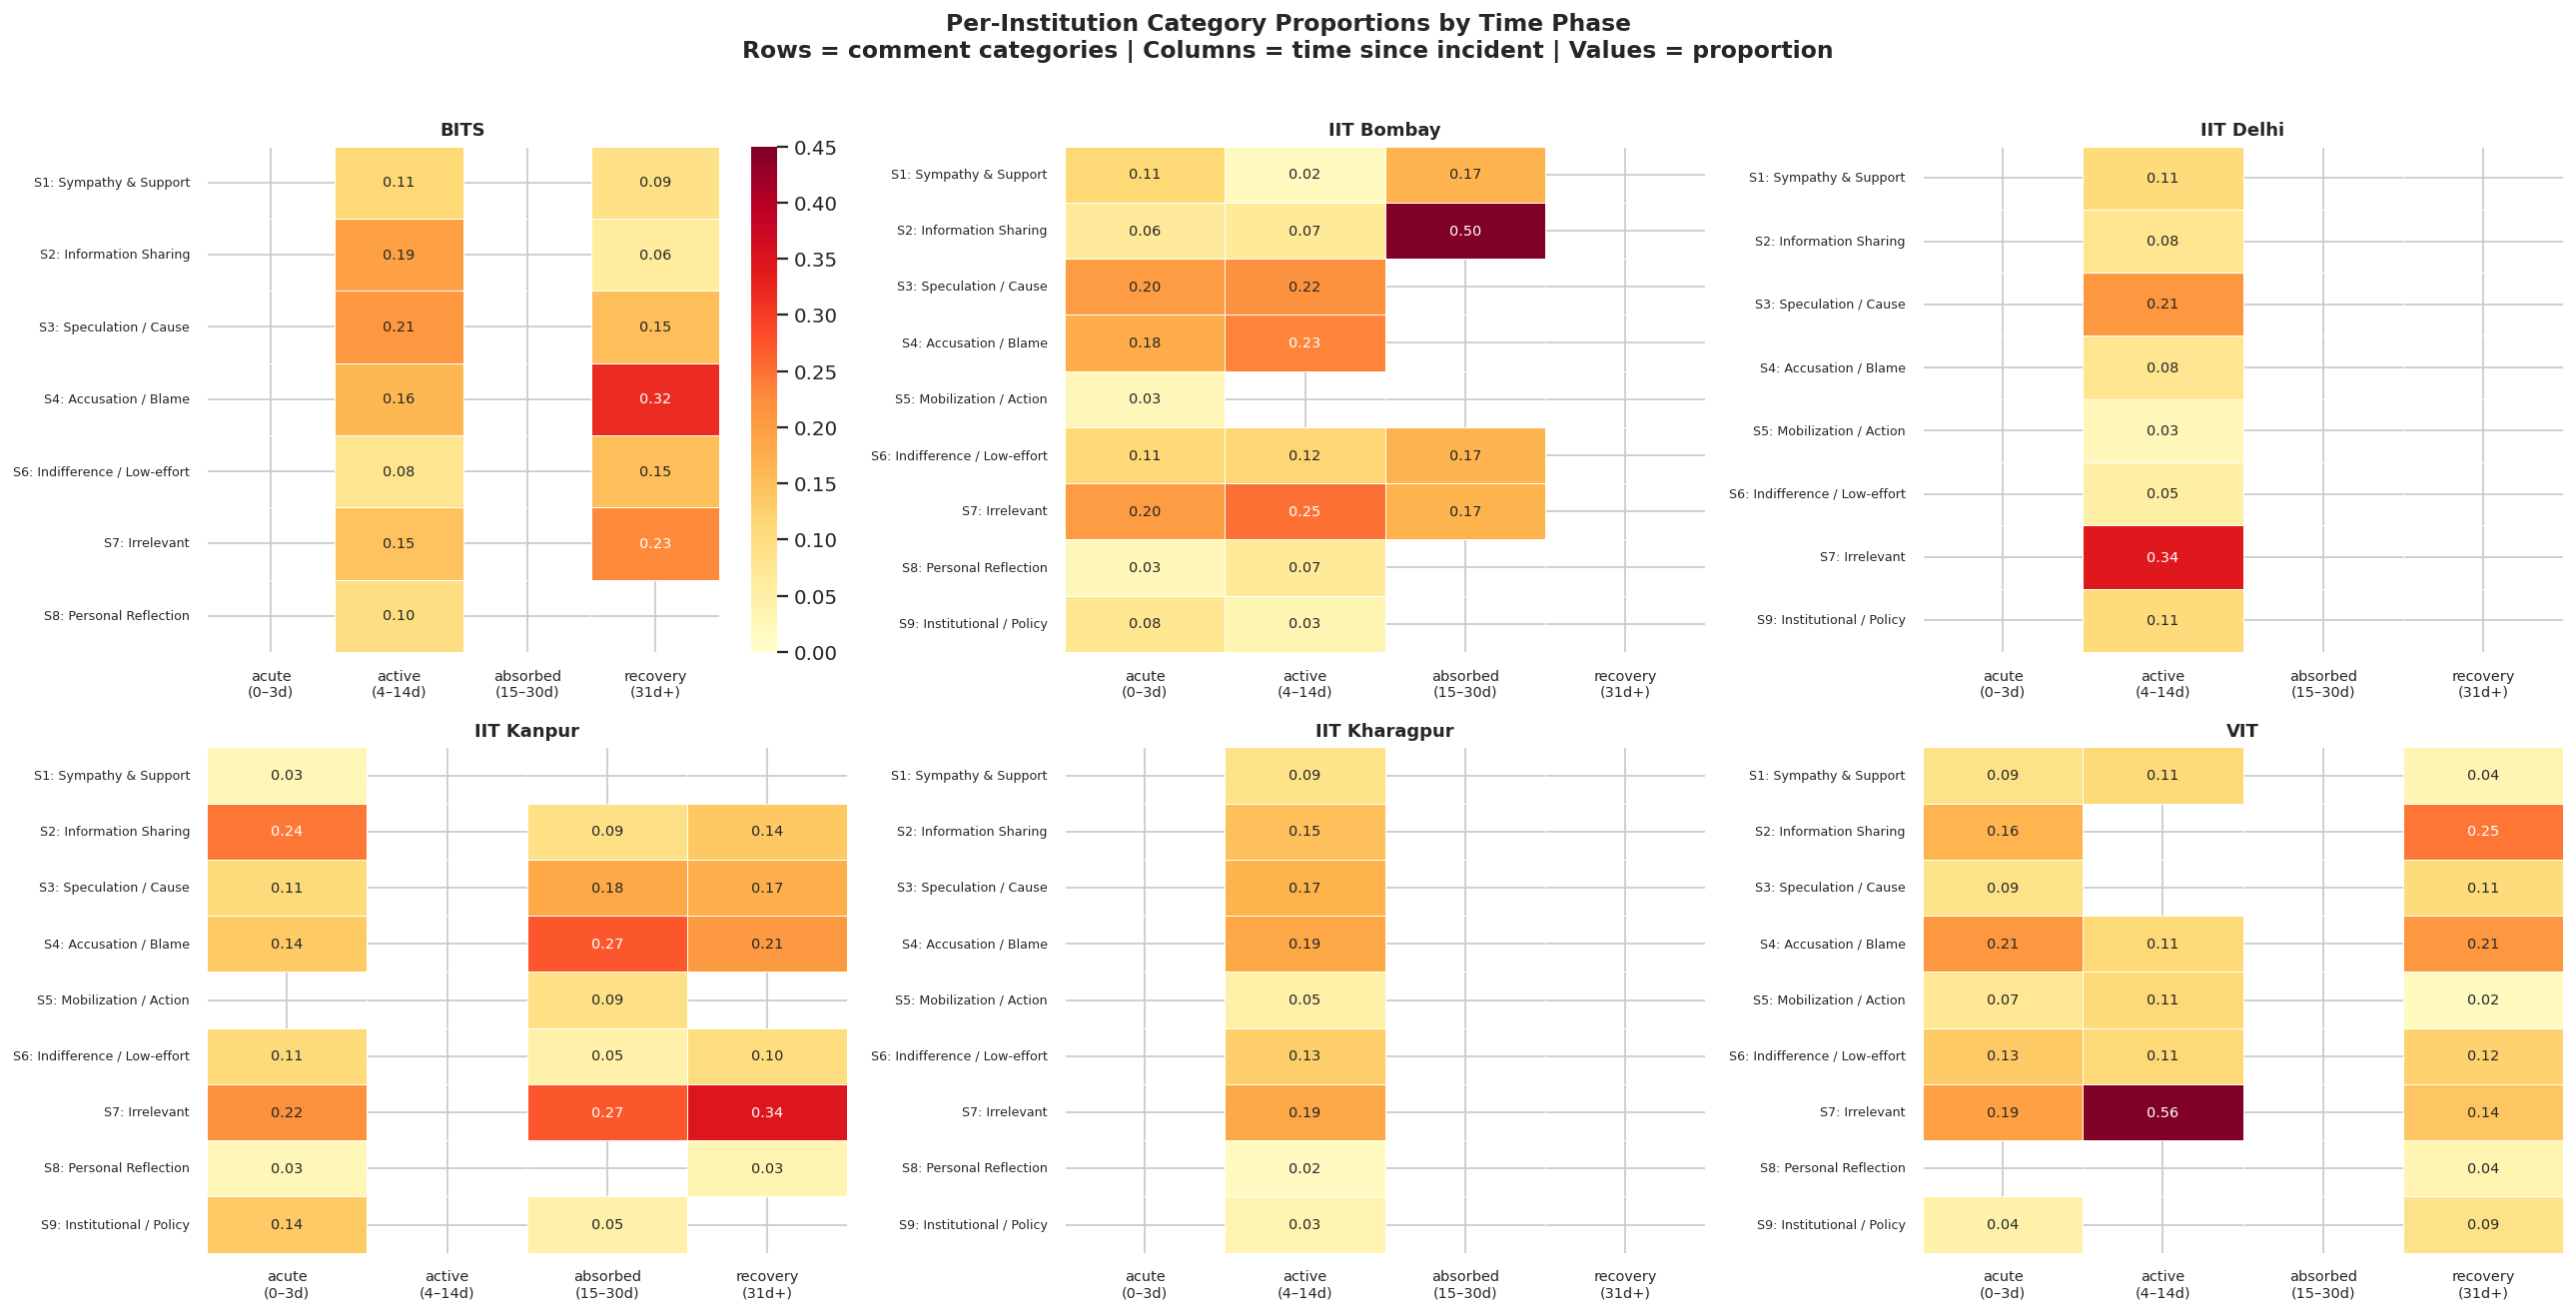

In [ ]:
per_inc_pivots = {}
for inc, grp in prop.groupby("incident_id"):
    piv = grp.pivot_table(index="category_code", columns="time_phase",
                           values="proportion", aggfunc="mean")
    piv = piv.reindex(columns=PHASE_ORDER)
    piv.index = [f"{c}: {CATEGORY_LABELS.get(c,c)}" for c in piv.index]
    per_inc_pivots[inc] = piv

incidents_list = sorted(per_inc_pivots.keys())
n_inc = len(incidents_list)
ncols = 3
nrows = (n_inc + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 5))
axes = axes.ravel()

for i, inc in enumerate(incidents_list):
    piv = per_inc_pivots[inc]
    for p in PHASE_ORDER:
        if p not in piv.columns:
            piv[p] = 0.0
    piv = piv[PHASE_ORDER]

    sns.heatmap(
        piv, ax=axes[i],
        cmap="YlOrRd", vmin=0, vmax=0.45,
        annot=True, fmt=".2f", annot_kws={"size": 8},
        linewidths=0.4, cbar=(i == 0)
    )
    axes[i].set_title(inc, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xticklabels([f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER],
                             fontsize=8, rotation=0)
    axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Per-Institution Category Proportions by Time Phase\n"    "Rows = comment categories | Columns = time since incident | Values = proportion",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("fig2_per_incident_heatmaps.png", dpi=130, bbox_inches="tight")
plt.show()


## Incident Salience Decay

Before fitting the IOHMM, we visualise the salience input X_t — the signal that drives
state transitions.

`X_t = exp(−λ · days_since_incident)`, with λ = log(2)/7 (half-life = 7 days).
This matches empirical patterns of social-media attention decay after news events.


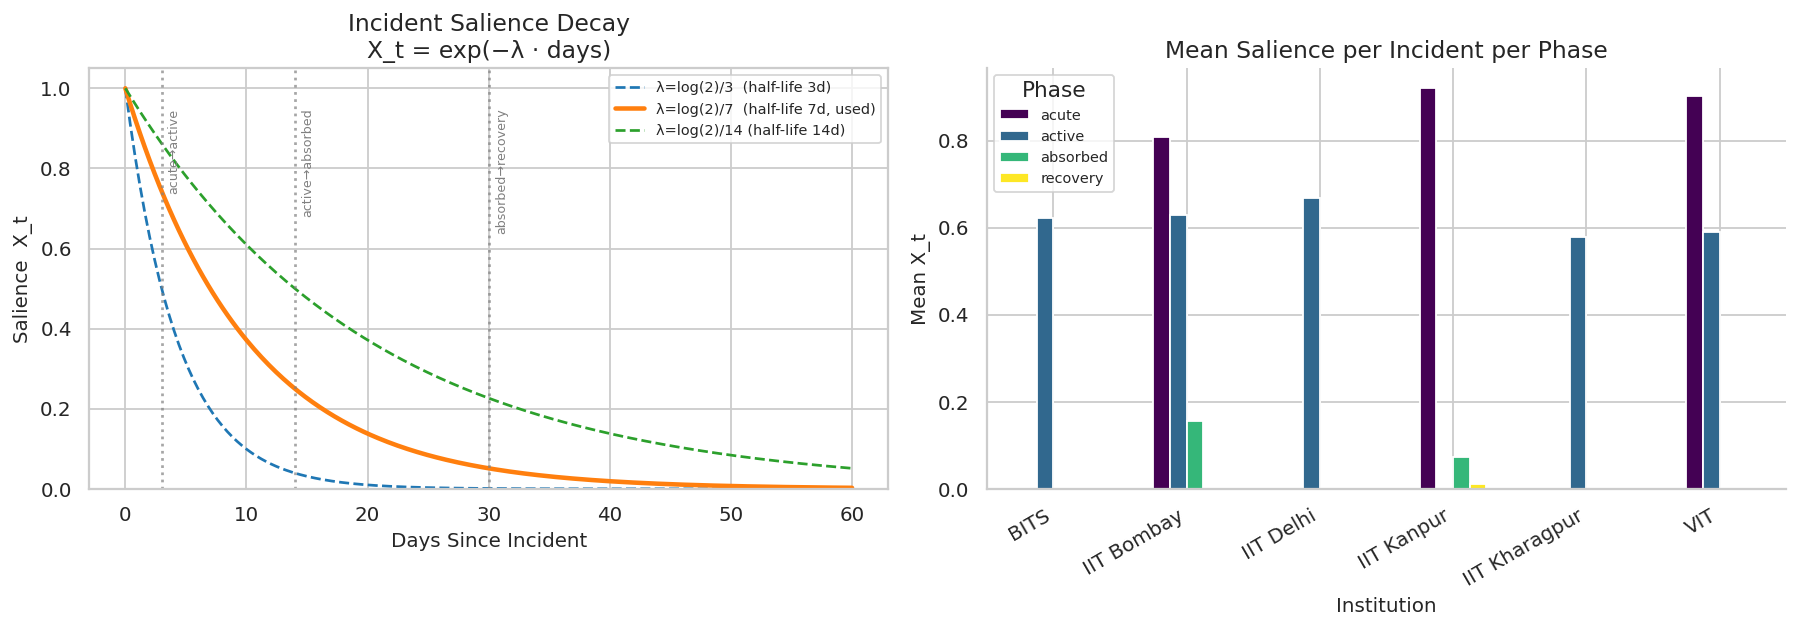

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

days = np.linspace(0, 60, 300)
lam_vals = {
    "λ=log(2)/3  (half-life 3d)":        np.log(2)/3,
    "λ=log(2)/7  (half-life 7d, used)":  np.log(2)/7,
    "λ=log(2)/14 (half-life 14d)":       np.log(2)/14,
}
for lbl, lv in lam_vals.items():
    ls = "-" if "used" in lbl else "--"
    lw = 2.5 if "used" in lbl else 1.5
    axes[0].plot(days, np.exp(-lv * days), label=lbl, linewidth=lw, linestyle=ls)

for boundary, phase in zip([3, 14, 30], ["acute→active", "active→absorbed", "absorbed→recovery"]):
    axes[0].axvline(boundary, color="gray", linestyle=":", alpha=0.7)
    axes[0].text(boundary + 0.5, 0.95, phase, fontsize=7, color="gray", rotation=90, va="top")

axes[0].set_xlabel("Days Since Incident")
axes[0].set_ylabel("Salience  X_t")
axes[0].set_title("Incident Salience Decay\nX_t = exp(−λ · days)")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.05)

# Mean salience per phase per incident
mean_sal = df.groupby(["incident_id", "time_phase"], observed=True)["incident_salience"].mean().unstack()
for col in PHASE_ORDER:
    if col not in mean_sal.columns:
        mean_sal[col] = np.nan
mean_sal = mean_sal[PHASE_ORDER]

mean_sal.plot(kind="bar", ax=axes[1], colormap="viridis", edgecolor="white")
axes[1].set_title("Mean Salience per Incident per Phase")
axes[1].set_xlabel("Institution")
axes[1].set_ylabel("Mean X_t")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].legend(title="Phase", fontsize=8)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig3_salience_decay.png", dpi=150, bbox_inches="tight")
plt.show()


## Building Sequences for the IOHMM

For each incident, we build a **sequence of observation vectors** — one per time phase.
Each observation vector is the proportion of each category in that phase (9-dimensional).
The corresponding salience X_t is the mean incident_salience in that phase.

Only incidents with ≥ 2 phases of data are used for model fitting.


In [ ]:
def build_sequences(df, prop_df):
    sequences, intensities, incident_names = [], [], []

    mean_sal = (
        df.groupby(["incident_id", "time_phase"], observed=True)["incident_salience"]
          .mean()
          .reset_index()
    )

    for inc in sorted(df["incident_id"].unique()):
        seq, intv = [], []
        last_sal = 0.5
        for phase in PHASE_ORDER:
            sub_prop = prop_df[(prop_df["incident_id"] == inc) &
                               (prop_df["time_phase"] == phase)]
            sub_sal  = mean_sal[(mean_sal["incident_id"] == inc) &
                                (mean_sal["time_phase"] == phase)]
            if len(sub_prop) == 0 or len(sub_sal) == 0:
                seq.append(np.zeros(N_CATS))
                intv.append(last_sal * 0.5)
                last_sal = last_sal * 0.5
                continue

            obs_vec = np.zeros(N_CATS)
            for _, row in sub_prop.iterrows():
                if row["category_code"] in CATEGORY_ORDER:
                    idx = CATEGORY_ORDER.index(row["category_code"])
                    obs_vec[idx] = row["proportion"]
            obs_vec /= (obs_vec.sum() + 1e-9)

            seq.append(obs_vec)
            sal_val = sub_sal["incident_salience"].values[0]
            intv.append(sal_val)
            last_sal = sal_val

        if len(seq) >= 1:
            sequences.append(np.array(seq))
            intensities.append(np.array(intv))
            incident_names.append(inc)

    return sequences, intensities, incident_names

sequences, intensities, incident_names = build_sequences(df, prop)

print(f"Usable incidents: {len(sequences)}")
print()
for inc, seq, intv in zip(incident_names, sequences, intensities):
    print(f"  {inc:<25}  T={len(seq)}  salience range [{intv.min():.3f}, {intv.max():.3f}]")


Usable incidents: 6

  BITS                       T=4  salience range [0.002, 0.623]
  IIT Bombay                 T=4  salience range [0.078, 0.809]
  IIT Delhi                  T=4  salience range [0.167, 0.669]
  IIT Kanpur                 T=4  salience range [0.010, 0.921]
  IIT Kharagpur              T=4  salience range [0.145, 0.580]
  VIT                        T=4  salience range [0.001, 0.902]


## The IOHMM: Theory & Implementation

### Why an Input-Output HMM?

The category proportions we observe are *indirect* traces of the latent collective
emotional state. Standard HMMs assume stationary transitions — but we *know* that
incident salience is changing (decaying). An IOHMM lets the transition matrix be a
**function of X_t**:

```
A(X_t)[i,j] = softmax( W[i,j] + v[i,j] · X_t )
```

- **W[i,j]**: baseline tendency to transition from state i → j
- **v[i,j]**: how much salience amplifies or suppresses that transition

A positive v[i,j] means: when the incident is salient, transitions i→j are more likely
(e.g., high salience keeps discourse in "acute blame" state).
A negative v[i,j] means: this transition is suppressed during high-salience periods.

### Emission model
Each latent state k emits a category proportion vector via cross-entropy:
```
log P(B_t | S_t = k) = obs_vec · log_B_normalized[k]
```


In [ ]:
class IOHMM:
    """
    Input-Output Hidden Markov Model for Reddit suicide discourse.

    Latent states: K (collective response phases)
    Observations:  9-dimensional category proportion vectors
    Input:         X_t = incident salience at time t

    Transition: A(X_t)[i,j] = softmax_j( W[i,j] + v[i,j]*X_t )
    Emission:   log P(B_t|S_t=k) = obs_vec . log_B_normalized[k]
    """

    def __init__(self, n_states=3, n_obs=9, random_state=42):
        self.K   = n_states
        self.D   = n_obs
        self.rng = np.random.default_rng(random_state)

    def _n_params(self):
        return self.K + self.K*self.K + self.K*self.K + self.K*self.D

    def _unpack(self, params):
        K, D = self.K, self.D
        i = 0
        log_pi = params[i:i+K];               i += K
        W_A    = params[i:i+K*K].reshape(K,K); i += K*K
        v_A    = params[i:i+K*K].reshape(K,K); i += K*K
        log_B  = params[i:i+K*D].reshape(K,D)
        return log_pi, W_A, v_A, log_B

    def _init_params(self):
        K, D = self.K, self.D
        log_pi = np.zeros(K)
        W_A    = self.rng.normal(0, 0.3, (K, K))
        v_A    = self.rng.normal(0, 0.3, (K, K))
        log_B  = self.rng.normal(0, 0.3, (K, D))
        return np.concatenate([log_pi, W_A.ravel(), v_A.ravel(), log_B.ravel()])

    def _transition(self, W_A, v_A, x_t):
        logits = W_A + v_A * x_t
        logits -= logits.max(axis=1, keepdims=True)
        A = np.exp(logits)
        A /= A.sum(axis=1, keepdims=True)
        return A

    def _log_emission(self, log_B, obs_vec):
        log_B_norm = log_B - logsumexp(log_B, axis=1, keepdims=True)
        return log_B_norm @ obs_vec

    def _forward(self, params, obs_seq, int_seq):
        log_pi, W_A, v_A, log_B = self._unpack(params)
        T, K = len(obs_seq), self.K
        alpha = np.full((T, K), -np.inf)

        pi       = log_pi - logsumexp(log_pi)
        alpha[0] = pi + self._log_emission(log_B, obs_seq[0])

        for t in range(1, T):
            A     = self._transition(W_A, v_A, int_seq[t])
            log_A = np.log(A + 1e-300)
            for j in range(K):
                alpha[t, j] = logsumexp(alpha[t-1] + log_A[:, j]) +                                self._log_emission(log_B, obs_seq[t])[j]

        return logsumexp(alpha[-1]), alpha

    def _neg_log_lik(self, params):
        total = 0.0
        for obs_seq, int_seq in zip(self._fit_seqs, self._fit_ints):
            ll, _ = self._forward(params, obs_seq, int_seq)
            total += ll
        return -total

    def fit(self, sequences, intensities, n_restarts=8, verbose=True):
        self._fit_seqs = sequences
        self._fit_ints = intensities
        best_ll, best_params = -np.inf, None

        for r in range(n_restarts):
            p0 = self._init_params() + self.rng.normal(0, 0.1, self._n_params())
            try:
                res = minimize(self._neg_log_lik, p0,
                               method="L-BFGS-B",
                               options={"maxiter": 500, "ftol": 1e-9})
                ll = -res.fun
                if verbose:
                    print(f"  restart {r+1}/{n_restarts}: ll={ll:.4f}")
                if ll > best_ll:
                    best_ll, best_params = ll, res.x
            except Exception as e:
                if verbose:
                    print(f"  restart {r+1} failed: {e}")

        self.params_  = best_params
        self.log_lik_ = best_ll

        # extract interpretable params
        log_pi, W_A, v_A, log_B = self._unpack(best_params)
        self.pi_ = np.exp(log_pi - logsumexp(log_pi))

        # baseline transition matrix (X=0)
        self.A_base_ = self._transition(W_A, v_A, 0.0)
        # high-salience transition matrix (X=1)
        self.A_high_ = self._transition(W_A, v_A, 1.0)

        # emission matrix
        log_B_norm = log_B - logsumexp(log_B, axis=1, keepdims=True)
        self.B_ = np.exp(log_B_norm)

        return self

    def decode(self, obs_seq, int_seq):
        """Viterbi decoding."""
        log_pi, W_A, v_A, log_B = self._unpack(self.params_)
        T, K = len(obs_seq), self.K
        viterbi = np.full((T, K), -np.inf)
        backptr  = np.zeros((T, K), dtype=int)

        pi           = log_pi - logsumexp(log_pi)
        viterbi[0]   = pi + self._log_emission(log_B, obs_seq[0])

        for t in range(1, T):
            A     = self._transition(W_A, v_A, int_seq[t])
            log_A = np.log(A + 1e-300)
            for j in range(K):
                scores       = viterbi[t-1] + log_A[:, j]
                backptr[t,j] = np.argmax(scores)
                viterbi[t,j] = scores[backptr[t,j]] + self._log_emission(log_B, obs_seq[t])[j]

        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(viterbi[-1])
        for t in range(T-2, -1, -1):
            path[t] = backptr[t+1, path[t+1]]
        return path

    def aic(self):
        return 2 * self._n_params() - 2 * self.log_lik_

    def bic(self, n_obs):
        return self._n_params() * np.log(n_obs) - 2 * self.log_lik_

    def simulate(self, int_seq, n_trials=50):
        log_pi, W_A, v_A, log_B = self._unpack(self.params_)
        T = len(int_seq)
        log_B_norm = log_B - logsumexp(log_B, axis=1, keepdims=True)
        B = np.exp(log_B_norm)
        pi = np.exp(log_pi - logsumexp(log_pi))

        all_states, all_obs = [], []
        for _ in range(n_trials):
            states, obs = [], []
            s = self.rng.choice(self.K, p=pi)
            states.append(s)
            obs.append(B[s])
            for t in range(1, T):
                A = self._transition(W_A, v_A, int_seq[t])
                s = self.rng.choice(self.K, p=A[s])
                states.append(s)
                obs.append(B[s])
            all_states.append(states)
            all_obs.append(obs)
        return all_states, all_obs

print("IOHMM class defined.")


IOHMM class defined.


## Fit IOHMM: Model Selection (K = 2, 3, 4)

We try K=2, 3, 4 latent states and select the best by **BIC**
(penalises complexity more strongly than AIC, appropriate for our small dataset).


In [ ]:
print("Fitting IOHMM for K = 2, 3, 4 states...")
print("(Multiple restarts per K to avoid local optima)\n")

n_obs_total = sum(len(s) for s in sequences)
fit_results = {}

for K in [2, 3, 4]:
    print(f"── K = {K} ──")
    model = IOHMM(n_states=K, n_obs=N_CATS, random_state=42)
    model.fit(sequences, intensities, n_restarts=8, verbose=True)
    fit_results[K] = {
        "model":    model,
        "log_lik":  model.log_lik_,
        "AIC":      model.aic(),
        "BIC":      model.bic(n_obs_total),
        "n_params": model._n_params(),
    }
    print(f"   → log-lik={model.log_lik_:.2f}  AIC={model.aic():.2f}  BIC={model.bic(n_obs_total):.2f}\n")

print("\n{:<6} {:>10} {:>10} {:>10} {:>10}".format("K","log-lik","AIC","BIC","#params"))
print("-"*50)
for K, r in fit_results.items():
    print("{:<6} {:>10.2f} {:>10.2f} {:>10.2f} {:>10}".format(
        K, r["log_lik"], r["AIC"], r["BIC"], r["n_params"]))

best_K = min(fit_results, key=lambda k: fit_results[k]["BIC"])
model  = fit_results[best_K]["model"]
print(f"\nSelected K = {best_K} by BIC.")


Fitting IOHMM for K = 2, 3, 4 states...
(Multiple restarts per K to avoid local optima)

── K = 2 ──
  restart 1/8: ll=-25.6397
  restart 2/8: ll=-25.6397
  restart 3/8: ll=-25.6397
  restart 4/8: ll=-25.6397
  restart 5/8: ll=-25.6397
  restart 6/8: ll=-25.6397
  restart 7/8: ll=-25.6397
  restart 8/8: ll=-25.6397
   → log-lik=-25.64  AIC=107.28  BIC=140.26

── K = 3 ──
  restart 1/8: ll=-25.4339
  restart 2/8: ll=-25.3800
  restart 3/8: ll=-25.4339
  restart 4/8: ll=-25.3800
  restart 5/8: ll=-25.3800
  restart 6/8: ll=-25.3800
  restart 7/8: ll=-25.3800
  restart 8/8: ll=-25.3800
   → log-lik=-25.38  AIC=146.76  BIC=203.31

── K = 4 ──
  restart 1/8: ll=-25.3801
  restart 2/8: ll=-25.4339
  restart 3/8: ll=-25.3800
  restart 4/8: ll=-25.4339
  restart 5/8: ll=-25.2210
  restart 6/8: ll=-25.4339
  restart 7/8: ll=-25.3800
  restart 8/8: ll=-25.3800
   → log-lik=-25.22  AIC=194.44  BIC=279.26


K         log-lik        AIC        BIC    #params
----------------------------------------

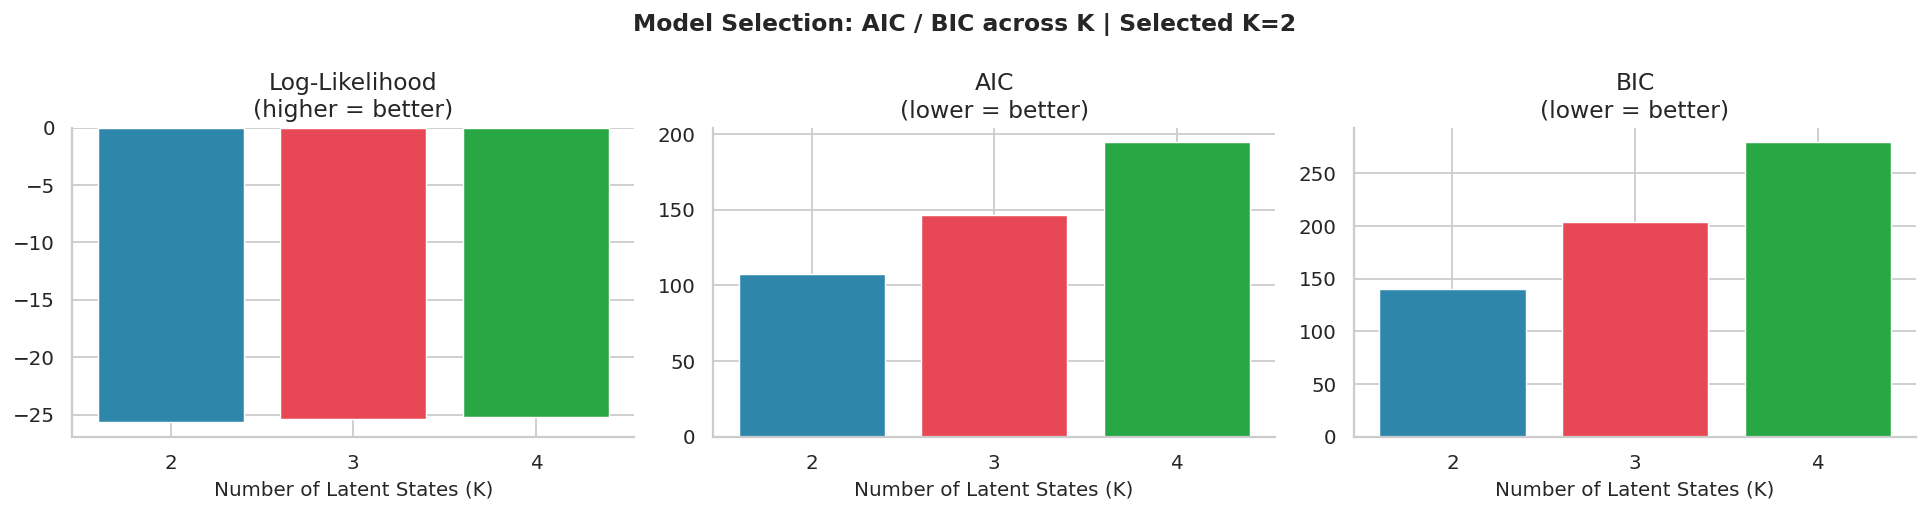

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
Ks       = list(fit_results.keys())
ll_vals  = [fit_results[k]["log_lik"] for k in Ks]
aic_vals = [fit_results[k]["AIC"]     for k in Ks]
bic_vals = [fit_results[k]["BIC"]     for k in Ks]
palette  = {2: "#2E86AB", 3: "#E84855", 4: "#28A745"}
bar_cols = [palette[k] for k in Ks]

for ax, vals, title, note in zip(
        axes,
        [ll_vals, aic_vals, bic_vals],
        ["Log-Likelihood", "AIC", "BIC"],
        ["higher = better", "lower = better", "lower = better"]):
    ax.bar(Ks, vals, color=bar_cols, edgecolor="white", linewidth=0.8)
    ax.set_xticks(Ks)
    ax.set_xlabel("Number of Latent States (K)")
    ax.set_title(f"{title}\n({note})")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(f"Model Selection: AIC / BIC across K | Selected K={best_K}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_model_selection.png", dpi=150, bbox_inches="tight")
plt.show()


## Emission Matrix: What Each Latent State "Talks About"

B[k, d] = P(category d | latent state k) tells us the psychological profile of each state.

Expected interpretations:
- A state high on **S4 Accusation + S2 Information** = *acute crisis / blame state*
- A state high on **S1 Sympathy + S8 Personal Reflection** = *grief / absorption state*
- A state high on **S9 Institutional + S3 Speculation** = *recovery / policy state*


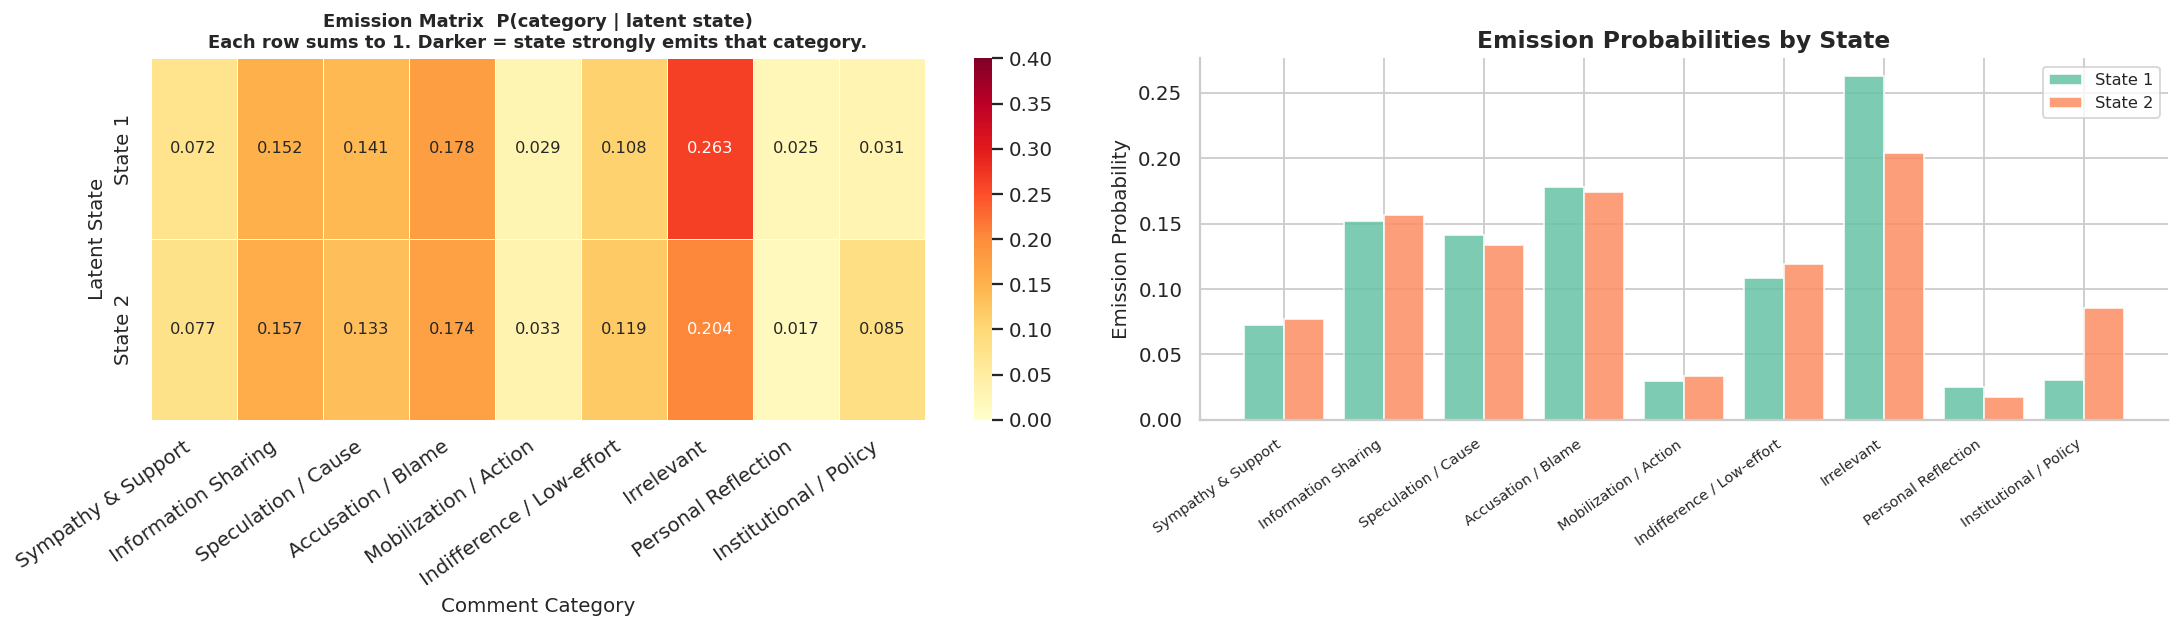

In [ ]:
short_cats   = [f"{c}" for c in CATEGORY_ORDER]
cat_full     = [CATEGORY_LABELS[c] for c in CATEGORY_ORDER]
state_names  = [f"State {k+1}" for k in range(best_K)]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

B_df = pd.DataFrame(model.B_, columns=cat_full, index=state_names)
sns.heatmap(B_df, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[0], vmin=0, vmax=0.4,
            annot_kws={"size": 9})
axes[0].set_title("Emission Matrix  P(category | latent state)\n"                   "Each row sums to 1. Darker = state strongly emits that category.",
                   fontsize=10, fontweight="bold")
axes[0].set_xlabel("Comment Category")
axes[0].set_ylabel("Latent State")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right")

state_colors = sns.color_palette("Set2", n_colors=best_K)
x = np.arange(N_CATS)
bar_width = 0.8 / best_K
for k in range(best_K):
    offset = (k - best_K/2 + 0.5) * bar_width
    axes[1].bar(x + offset, model.B_[k], width=bar_width,
                label=f"State {k+1}", color=state_colors[k], alpha=0.85, edgecolor="white")

axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_full, rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("Emission Probability")
axes[1].set_title("Emission Probabilities by State", fontweight="bold")
axes[1].legend()
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig5_emission_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## Transition Matrices: How States Change With Salience

The IOHMM has *two* informative transition matrices:
- **A_high** (X=1, day 0): transitions when incident is maximally salient
- **A_base** (X=0, day 30+): transitions when incident has faded from attention

Comparing the two reveals which state switches are **driven by salience** vs which are
**structural** (happen regardless of incident intensity).


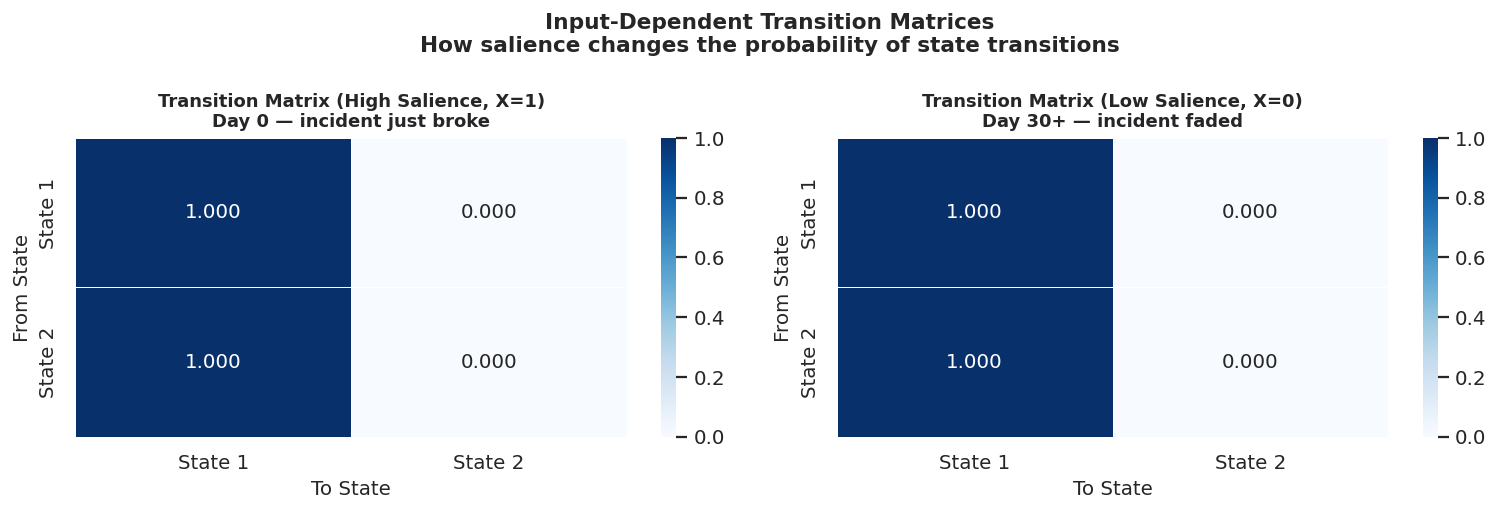

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, A, title in zip(axes,
                         [model.A_high_, model.A_base_],
                         ["Transition Matrix (High Salience, X=1)\nDay 0 — incident just broke",
                          "Transition Matrix (Low Salience, X=0)\nDay 30+ — incident faded"]):
    A_df = pd.DataFrame(A, index=state_names, columns=state_names)
    sns.heatmap(A_df, annot=True, fmt=".3f", cmap="Blues",
                linewidths=0.5, ax=ax, vmin=0, vmax=1,
                annot_kws={"size": 11})
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("To State")
    ax.set_ylabel("From State")

plt.suptitle("Input-Dependent Transition Matrices\n"             "How salience changes the probability of state transitions",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig6_transition_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## Viterbi-Decoded State Trajectories

The **Viterbi algorithm** finds the most probable sequence of hidden states
for each institution's comment trajectory. This decodes the latent collective
response arc — going from observations back to states.


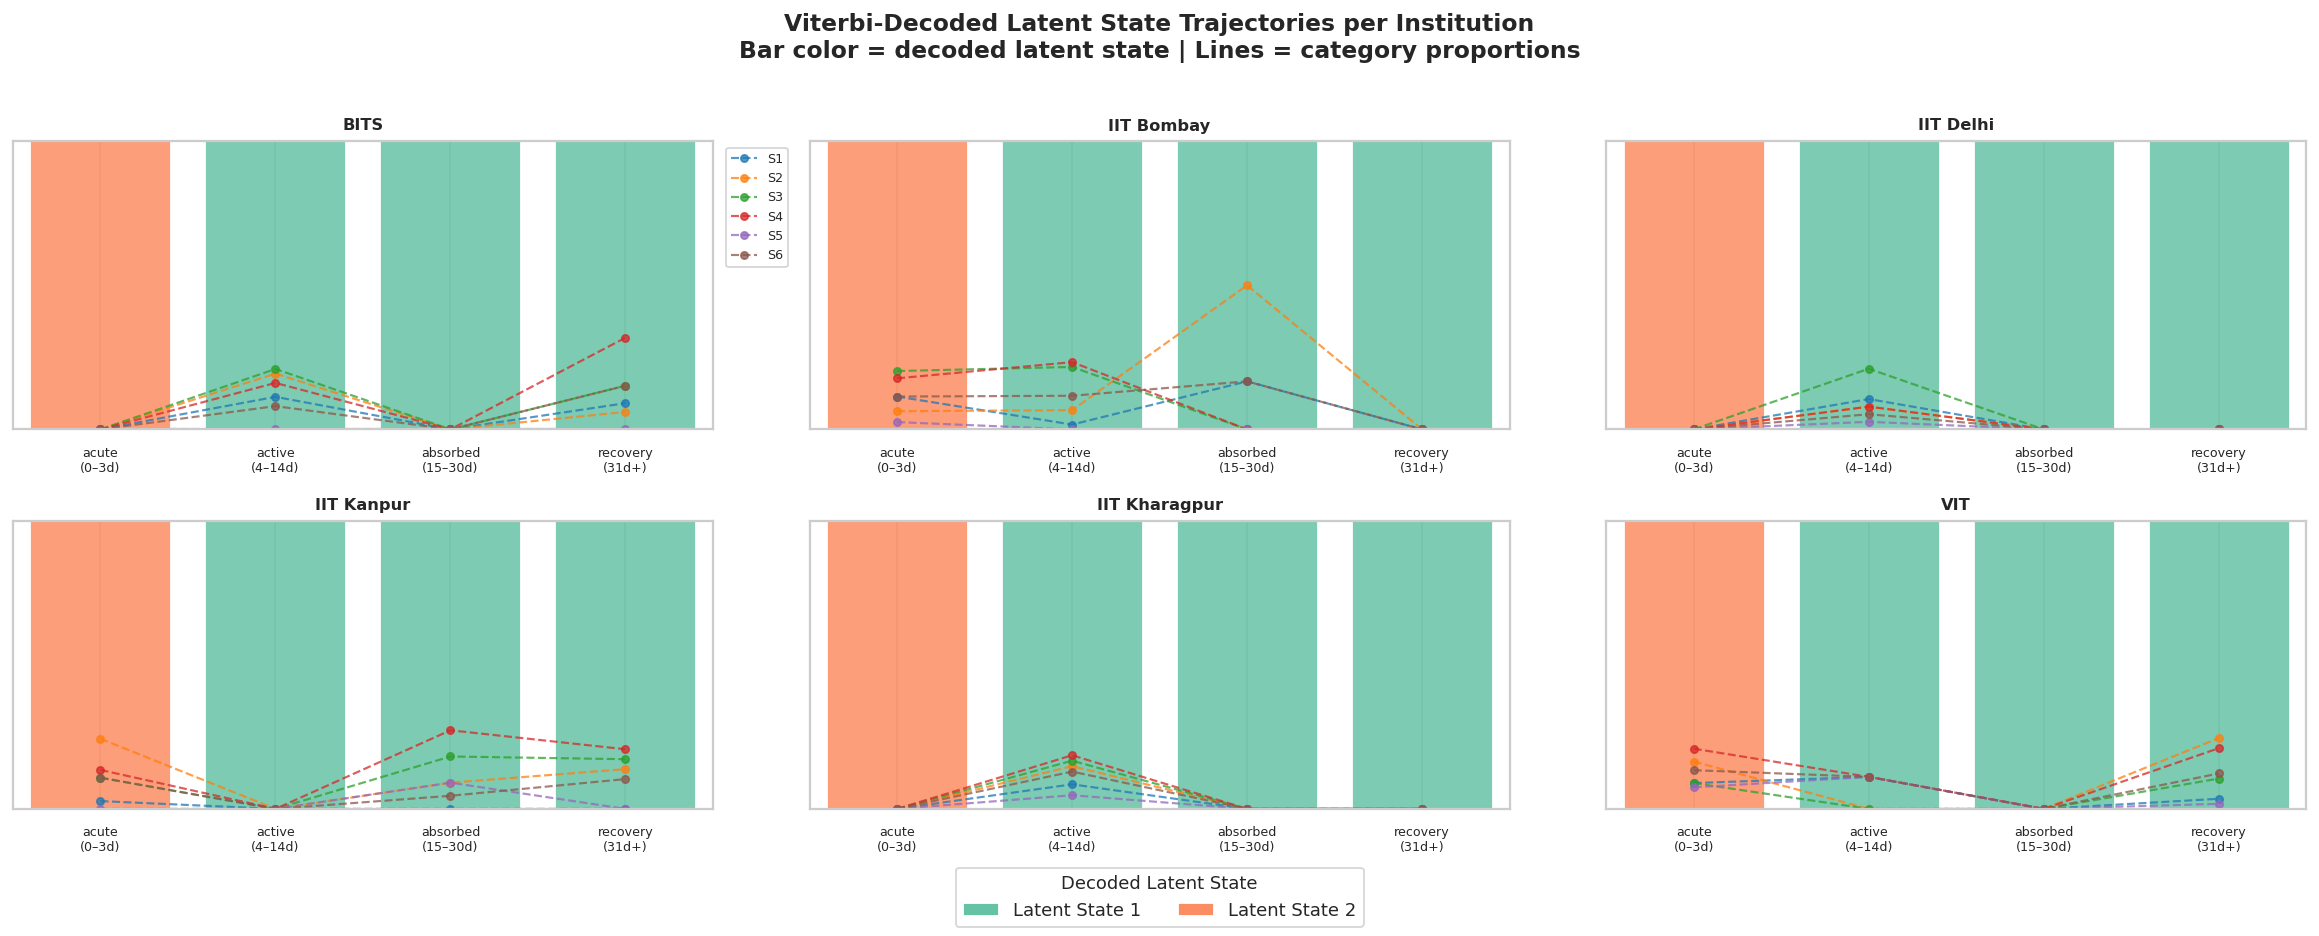

In [ ]:
phase_xlabels = [f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER]
state_colors  = sns.color_palette("Set2", n_colors=best_K)

n_inc = len(incident_names)
ncols = 3
nrows = (n_inc + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.ravel()

all_paths = []
for i, (inc, seq, intv) in enumerate(zip(incident_names, sequences, intensities)):
    path = model.decode(seq, intv)
    all_paths.append(path)
    T  = len(path)
    ax = axes[i]

    for t in range(T):
        ax.bar(t, 1, color=state_colors[path[t]], alpha=0.85, edgecolor="white", linewidth=0.5)

    for d, cat in enumerate(CATEGORY_ORDER[:6]):
        if d < seq.shape[1]:
            ax.plot(range(T), seq[:T, d], "o--",
                    linewidth=1.2, markersize=4,
                    color=COLORS[d], alpha=0.75, label=f"{cat}")

    ax.set_title(inc, fontsize=9, fontweight="bold")
    ax.set_xlim(-0.5, 3.5)
    ax.set_xticks(range(T))
    ax.set_xticklabels(phase_xlabels[:T], fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    if i == 0:
        ax.legend(bbox_to_anchor=(1.01,1), fontsize=7, loc="upper left")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

from matplotlib.patches import Patch
state_legend = [Patch(facecolor=state_colors[k], label=f"Latent State {k+1}")
                for k in range(best_K)]
fig.legend(handles=state_legend, loc="lower center",
           ncol=best_K, fontsize=10, title="Decoded Latent State", title_fontsize=10)

plt.suptitle(
    "Viterbi-Decoded Latent State Trajectories per Institution\n"    "Bar color = decoded latent state | Lines = category proportions",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("fig7_decoded_trajectories.png", dpi=130, bbox_inches="tight")
plt.show()


## Posterior Predictive Check

We simulate 100 trajectories from the fitted model and compare against observed proportions.
If the simulations match observations, the model has captured the real dynamics.


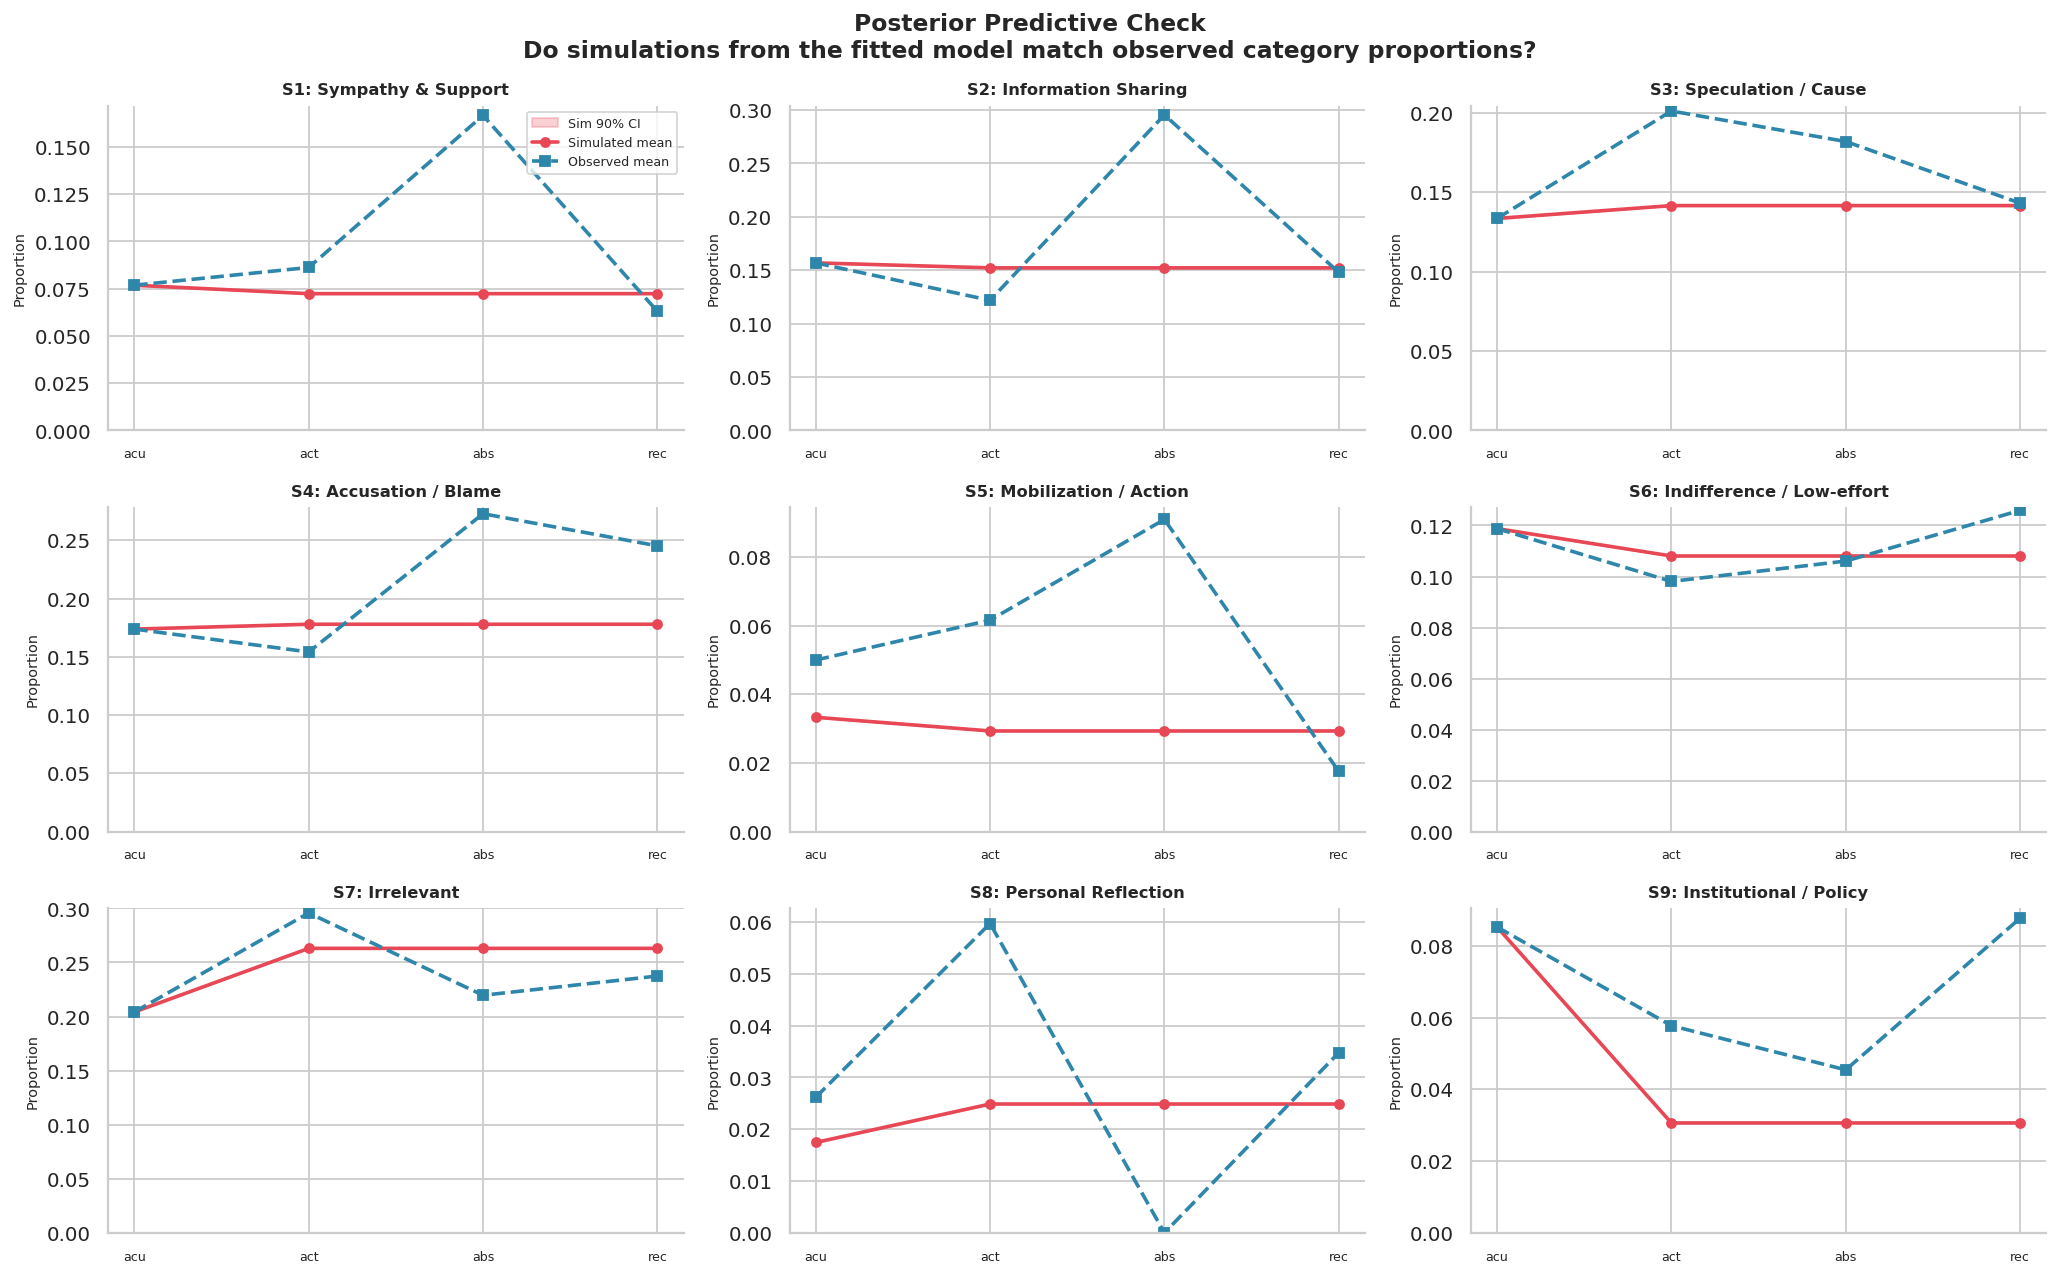

In [ ]:
mean_sal_profile = np.array([
    df[df["time_phase"] == p]["incident_salience"].mean()
    for p in PHASE_ORDER
])

N_SIM = 100
sim_states_all, sim_obs_all = model.simulate(mean_sal_profile, n_trials=N_SIM)
sim_obs_arr = np.array(sim_obs_all)   # (N_SIM, T, 9)

obs_mean = np.array([
    [agg[(agg["time_phase"] == p) & (agg["category_code"] == c)]["mean"].values[0]
     if len(agg[(agg["time_phase"] == p) & (agg["category_code"] == c)]) > 0
     else 0.0
     for c in CATEGORY_ORDER]
    for p in PHASE_ORDER
])  # (4, 9)

T = min(len(mean_sal_profile), obs_mean.shape[0])

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=False)
axes = axes.ravel()

for d, cat in enumerate(CATEGORY_ORDER):
    ax = axes[d]
    sim_d    = sim_obs_arr[:, :T, d]
    sim_mean = sim_d.mean(axis=0)
    sim_lo   = np.percentile(sim_d,  5, axis=0)
    sim_hi   = np.percentile(sim_d, 95, axis=0)

    x = np.arange(T)
    ax.fill_between(x, sim_lo, sim_hi, alpha=0.25, color="#E84855", label="Sim 90% CI")
    ax.plot(x, sim_mean, "o-", color="#E84855", linewidth=2, markersize=5, label="Simulated mean")
    ax.plot(x, obs_mean[:T, d], "s--", color="#2E86AB", linewidth=2, markersize=5, label="Observed mean")

    ax.set_title(f"{cat}: {CATEGORY_LABELS[cat]}", fontsize=9, fontweight="bold")
    ax.set_xticks(range(T))
    ax.set_xticklabels([p[:3] for p in PHASE_ORDER[:T]], fontsize=7)
    ax.set_ylabel("Proportion", fontsize=8)
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if d == 0:
        ax.legend(fontsize=7, loc="upper right")

plt.suptitle(
    "Posterior Predictive Check\n"    "Do simulations from the fitted model match observed category proportions?",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("fig8_posterior_predictive.png", dpi=150, bbox_inches="tight")
plt.show()


## Individual Models per Institution

We fit a separate IOHMM for each institution and compare metrics.
This tells us which institutions are well-explained by the combined model
and which are outliers with their own unique response arc.


In [ ]:
print("Fitting individual models per institution (K=2 and K=3)...\n")
ind_results = []

for inc, seq, intv in zip(incident_names, sequences, intensities):
    best = {"ll": -np.inf}
    for K in [2, 3]:
        m = IOHMM(n_states=K, n_obs=N_CATS, random_state=42)
        m.fit([seq], [intv], n_restarts=5, verbose=False)
        if m.log_lik_ > best["ll"]:
            best = {"ll": m.log_lik_, "K": K,
                    "AIC": m.aic(), "BIC": m.bic(len(seq))}
    ind_results.append({
        "Institution": inc,
        "Best K":      best["K"],
        "Log-Lik":     round(best["ll"], 2),
        "AIC":         round(best["AIC"], 2),
        "BIC":         round(best["BIC"], 2),
    })
    print(f"  {inc:<25} K={best['K']}  LL={best['ll']:7.2f}  AIC={best['AIC']:7.2f}  BIC={best['BIC']:7.2f}")

ind_df = pd.DataFrame(ind_results)
print("\n", ind_df.to_string(index=False))


Fitting individual models per institution (K=2 and K=3)...

  BITS                      K=3  LL=  -3.56  AIC= 103.11  BIC=  73.65
  IIT Bombay                K=3  LL=  -5.06  AIC= 106.12  BIC=  76.66
  IIT Delhi                 K=2  LL=  -1.82  AIC=  59.64  BIC=  42.46
  IIT Kanpur                K=3  LL=  -5.25  AIC= 106.50  BIC=  77.04
  IIT Kharagpur             K=2  LL=  -2.01  AIC=  60.02  BIC=  42.83
  VIT                       K=3  LL=  -5.24  AIC= 106.48  BIC=  77.03

   Institution  Best K  Log-Lik    AIC   BIC
         BITS       3    -3.56 103.11 73.65
   IIT Bombay       3    -5.06 106.12 76.66
    IIT Delhi       2    -1.82  59.64 42.46
   IIT Kanpur       3    -5.25 106.50 77.04
IIT Kharagpur       2    -2.01  60.02 42.83
          VIT       3    -5.24 106.48 77.03


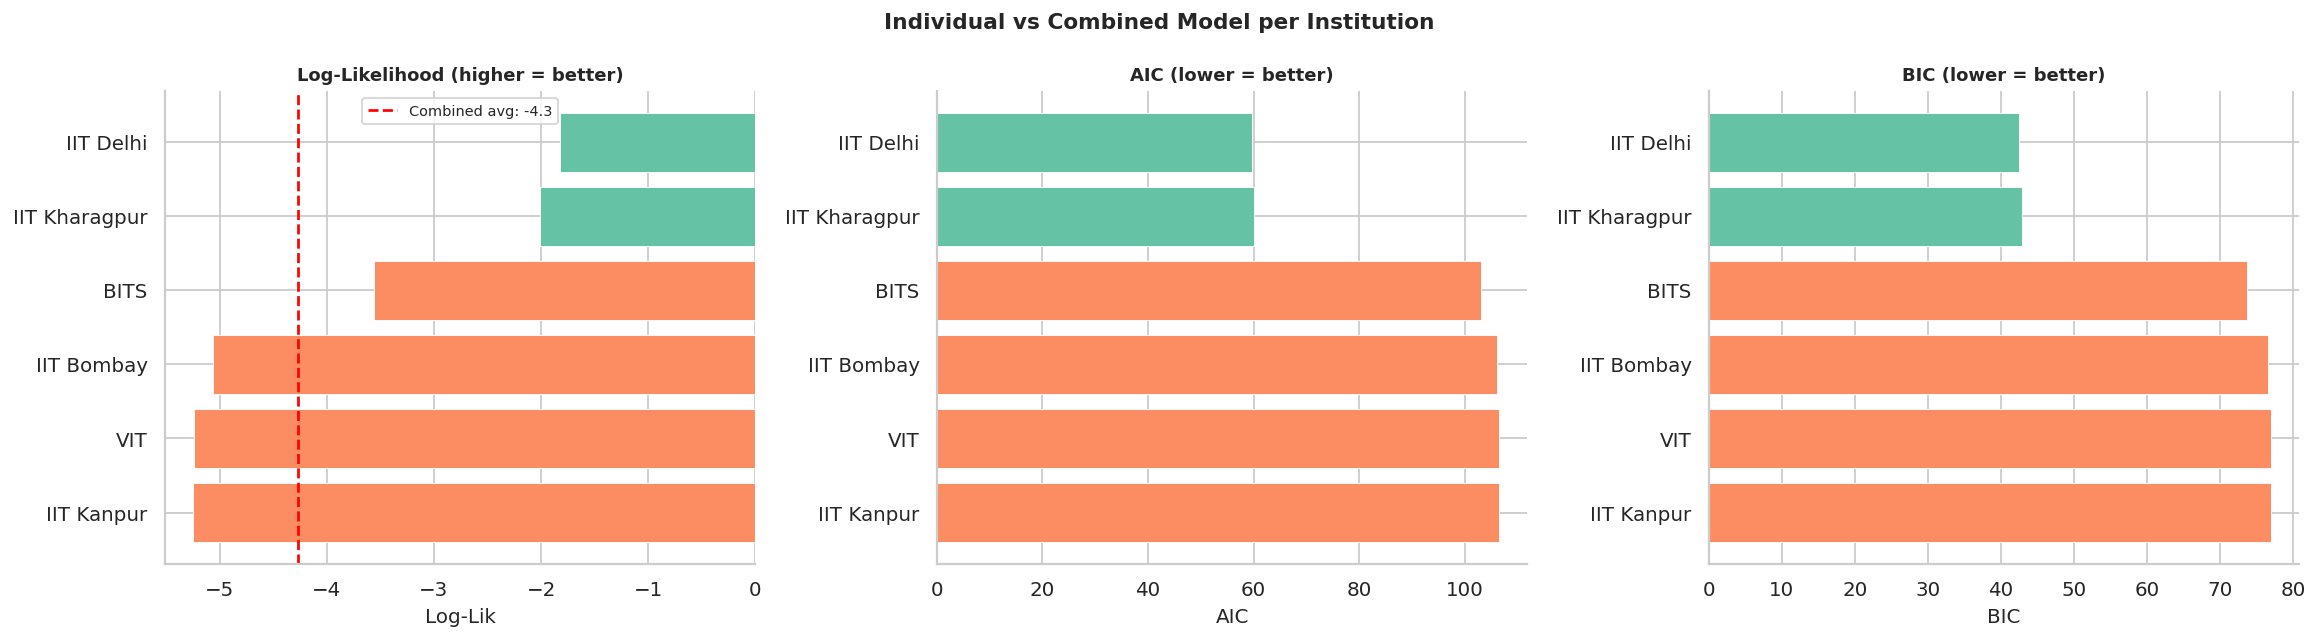

In [ ]:
ind_sorted  = ind_df.sort_values("Log-Lik")
bar_palette = sns.color_palette("Set2", n_colors=best_K)
bar_colors  = [bar_palette[r["Best K"]-2] for _, r in ind_sorted.iterrows()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(axes,
        ["Log-Lik", "AIC", "BIC"],
        ["Log-Likelihood (higher = better)", "AIC (lower = better)", "BIC (lower = better)"]):
    ax.barh(ind_sorted["Institution"], ind_sorted[metric],
            color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel(metric)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if metric == "Log-Lik":
        per_inc_ll = model.log_lik_ / len(incident_names)
        ax.axvline(per_inc_ll, color="red", linestyle="--", linewidth=1.5,
                   label=f"Combined avg: {per_inc_ll:.1f}")
        ax.legend(fontsize=8)

plt.suptitle("Individual vs Combined Model per Institution",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig9_individual_models.png", dpi=150, bbox_inches="tight")
plt.show()


## Leave-One-Institution-Out Cross-Validation

Train on N-1 institutions, evaluate on the held-out one. Repeat for each.
This answers: **does the model generalise?** — i.e., does it learn universal
patterns of suicide-related discourse, not just memorise the 6 specific trajectories?


In [ ]:
print("Leave-one-institution-out cross-validation...\n")
cv_lls = []

for i, held_inc in enumerate(incident_names):
    train_seqs = [s for j, s in enumerate(sequences)   if j != i]
    train_ints = [v for j, v in enumerate(intensities)  if j != i]
    test_seq   = sequences[i]
    test_int   = intensities[i]

    cv_model = IOHMM(n_states=best_K, n_obs=N_CATS, random_state=i)
    cv_model.fit(train_seqs, train_ints, n_restarts=5, verbose=False)

    ll_held, _ = cv_model._forward(cv_model.params_, test_seq, test_int)
    cv_lls.append(ll_held)
    print(f"  Held out: {held_inc:<25}  log-lik = {ll_held:.3f}")

mean_cv_ll = np.mean(cv_lls)
print(f"\n  Mean CV log-likelihood : {mean_cv_ll:.3f}")
print(f"  Training log-likelihood: {model.log_lik_:.3f}")
print(f"  Overfitting gap        : {model.log_lik_ - mean_cv_ll*len(incident_names):.3f}")


Leave-one-institution-out cross-validation...

  Held out: BITS                       log-lik = -3.996
  Held out: IIT Bombay                 log-lik = -6.109
  Held out: IIT Delhi                  log-lik = -2.051
  Held out: IIT Kanpur                 log-lik = -5.964
  Held out: IIT Kharagpur              log-lik = -2.056
  Held out: VIT                        log-lik = -6.155

  Mean CV log-likelihood : -4.388
  Training log-likelihood: -25.640
  Overfitting gap        : 0.691


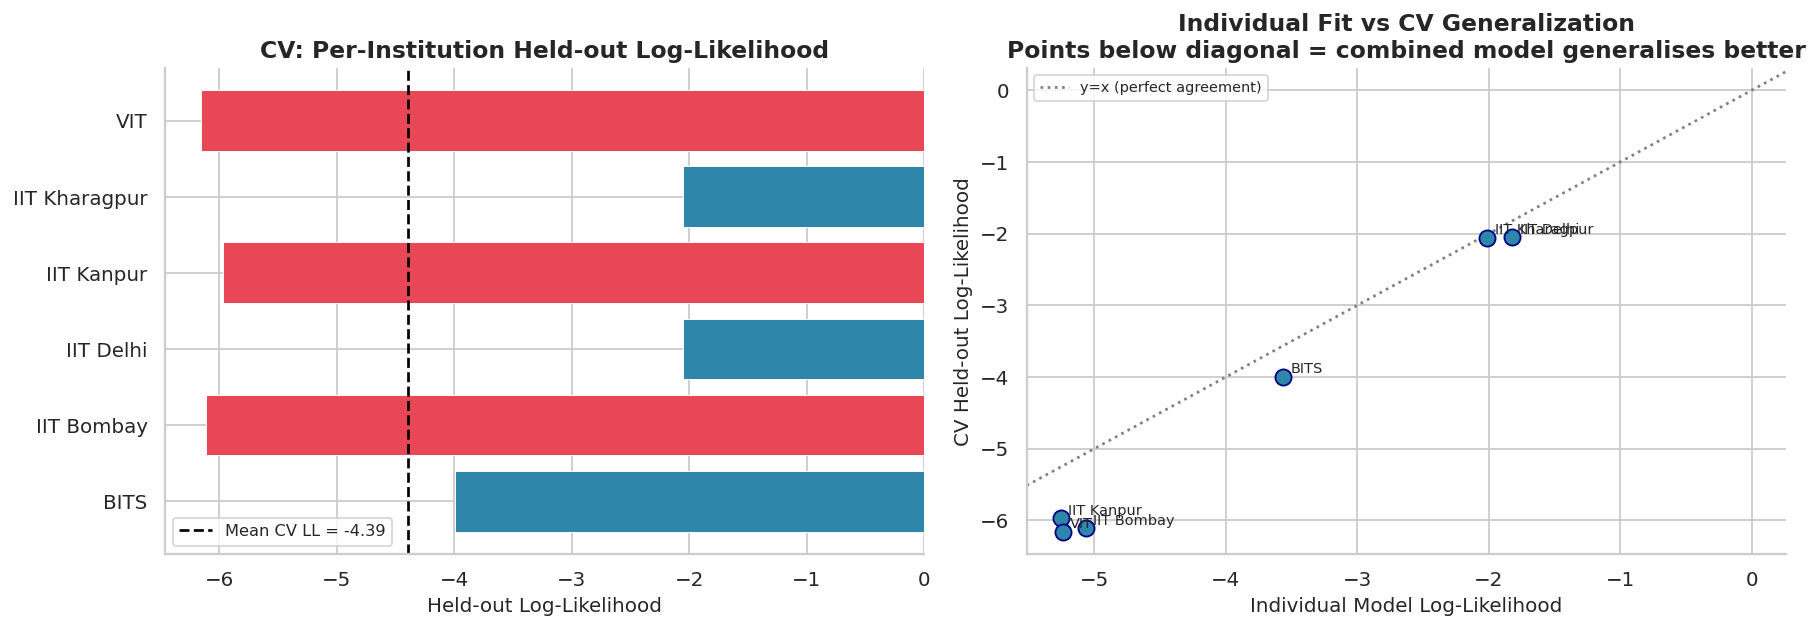

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cv_colors = ["#2E86AB" if ll > mean_cv_ll else "#E84855" for ll in cv_lls]
axes[0].barh(incident_names, cv_lls, color=cv_colors, edgecolor="white", linewidth=0.5)
axes[0].axvline(mean_cv_ll, color="black", linestyle="--", linewidth=1.5,
                label=f"Mean CV LL = {mean_cv_ll:.2f}")
axes[0].set_xlabel("Held-out Log-Likelihood")
axes[0].set_title("CV: Per-Institution Held-out Log-Likelihood", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

ind_lls_ordered = [
    ind_df[ind_df["Institution"] == inc]["Log-Lik"].values[0]
    if inc in ind_df["Institution"].values else np.nan
    for inc in incident_names
]
axes[1].scatter(ind_lls_ordered, cv_lls, s=80, color="#2E86AB", edgecolors="navy", zorder=3)
for x, y, name in zip(ind_lls_ordered, cv_lls, incident_names):
    if not np.isnan(x):
        axes[1].annotate(name, (x, y), fontsize=8, xytext=(4, 2), textcoords="offset points")
axes[1].axline((0, 0), slope=1, color="gray", linestyle=":", label="y=x (perfect agreement)")
axes[1].set_xlabel("Individual Model Log-Likelihood")
axes[1].set_ylabel("CV Held-out Log-Likelihood")
axes[1].set_title("Individual Fit vs CV Generalization\n"                   "Points below diagonal = combined model generalises better",
                   fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig10_cv_results.png", dpi=150, bbox_inches="tight")
plt.show()
